# CSAI415 — D2 Report: Retrieval Stack & Graph Build

**Deliverable:** D2 — Week 7 (15%)  
**Stack:** Python 3.11 · FastAPI · MongoDB · Qdrant · Neo4j · BAAI/bge-small-en-v1.5  
**Corpus:** 200 arXiv cs.AI papers


In [1]:
import json
import os
import sys
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from IPython.display import display, Image

sys.path.insert(0, '..')
os.makedirs('../docs', exist_ok=True)

print('Imports OK')

Imports OK


## 1. Ingestion Pipeline

The ingestion pipeline converts raw arXiv PDF files into searchable vector chunks stored across three datastores.

| Step | File | Description |
|------|------|-------------|
| 1 | `pdf_parser.py` | pdfplumber page extraction, hyphenation fix, metadata from CSV |
| 2 | `chunker.py` | Sliding window 400 tokens / 80 overlap, char offsets for citations |
| 3 | `embedder.py` | Boilerplate filter + bge-small-en-v1.5 384-dim embeddings |
| 4 | `qdrant_store.py` | Vectors + chunk_id payload |
| 5 | `mongo_store.py` | Full text + metadata + TTL run cards |
| 6 | `seed_neo4j.py` | Paper, Author, Topic, Venue nodes from papers_enriched.csv |

In [2]:
with open('../data/ingest_results.json') as f:
    ingest_results = json.load(f)

df_ingest = pd.DataFrame(ingest_results)

ok      = df_ingest[df_ingest['status'] == 'ok']
skipped = df_ingest[df_ingest['status'].str.contains('skipped', na=False)]
errors  = df_ingest[df_ingest['status'].str.contains('error|exception', na=False)]

summary = pd.DataFrame([
    {'Metric': 'Total papers',         'Value': len(df_ingest)},
    {'Metric': 'Successfully ingested','Value': len(ok)},
    {'Metric': 'Skipped (duplicate)',  'Value': len(skipped)},
    {'Metric': 'Errors',               'Value': len(errors)},
    {'Metric': 'Total chunks',         'Value': int(ok['chunks'].sum())},
    {'Metric': 'Total pages',          'Value': int(ok['pages'].sum())},
    {'Metric': 'Avg chunks / paper',   'Value': f"{ok['chunks'].mean():.1f}"},
    {'Metric': 'Avg pages / paper',    'Value': f"{ok['pages'].mean():.1f}"},
    {'Metric': 'Total ingest time',    'Value': f"{df_ingest['elapsed'].sum():.0f}s"},
])

display(summary.style.hide(axis='index'))

Metric,Value
Total papers,200
Successfully ingested,200
Skipped (duplicate),0
Errors,0
Total chunks,7979
Total pages,4862
Avg chunks / paper,39.9
Avg pages / paper,24.3
Total ingest time,129s


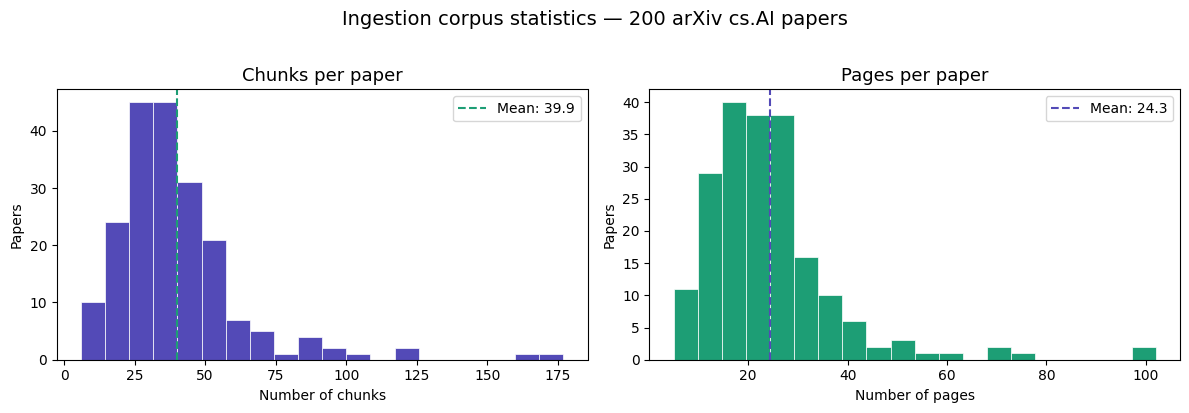

Saved to docs/d2_ingestion_stats.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ok['chunks'], bins=20, color='#534AB7', edgecolor='white', linewidth=0.5)
axes[0].set_title('Chunks per paper', fontsize=13)
axes[0].set_xlabel('Number of chunks')
axes[0].set_ylabel('Papers')
axes[0].axvline(ok['chunks'].mean(), color='#1D9E75', linestyle='--',
                linewidth=1.5, label=f"Mean: {ok['chunks'].mean():.1f}")
axes[0].legend()

axes[1].hist(ok['pages'], bins=20, color='#1D9E75', edgecolor='white', linewidth=0.5)
axes[1].set_title('Pages per paper', fontsize=13)
axes[1].set_xlabel('Number of pages')
axes[1].set_ylabel('Papers')
axes[1].axvline(ok['pages'].mean(), color='#534AB7', linestyle='--',
                linewidth=1.5, label=f"Mean: {ok['pages'].mean():.1f}")
axes[1].legend()

plt.suptitle('Ingestion corpus statistics — 200 arXiv cs.AI papers', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../docs/d2_ingestion_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to docs/d2_ingestion_stats.png')

## 2. Data Stores

| Store | Purpose | Key fields |
|-------|---------|------------|
| **Qdrant** | Vector similarity search | vector (384d), chunk_id, paper_id, page_num |
| **MongoDB** | Full text + metadata | chunk_id, text, title, authors, topics, char_start, char_end |
| **Neo4j** | Knowledge graph | Paper, Author, Topic, Venue + WROTE, ABOUT, PUBLISHED_IN |

**Chunk schema (MongoDB):**
```json
{
  "chunk_id":    "2605.06667v1_p2_c1",
  "paper_id":    "2605.06667v1",
  "page_num":    2,
  "chunk_index": 1,
  "text":        "...",
  "char_start":  512,
  "char_end":    2811,
  "title":       "ActCam: Zero-Shot Joint Camera...",
  "authors":     ["Omar El Khalifi", "..."],
  "topics":      ["planning_and_scheduling", "symbolic_ai"],
  "year":        2026
}
```

**Neo4j graph schema (Abdullah):**
```cypher
(Author)-[:WROTE]->(Paper)-[:ABOUT]->(Topic)
(Paper)-[:PUBLISHED_IN]->(Venue)
```

## 3. Hybrid Retrieval

The `/search` endpoint fuses two retrieval signals using Abdullah's `hybrid_retriever.py`:

- **Dense (Qdrant):** cosine similarity between bge-small-en-v1.5 query/chunk embeddings  
- **BM25 (rank-bm25):** lexical overlap between tokenized query and chunk texts

**Fusion formula:**
```
hybrid_score = alpha × bm25_score + (1 − alpha) × dense_score
```

Alpha is warm-started from the AutoML run card and adapts online via `HybridWeightAdapter` from D1.

In [4]:
with open('../run_card.yaml') as f:
    run_card = yaml.safe_load(f)

best = run_card.get('best_params', {})

rc_df = pd.DataFrame([
    {'Parameter': 'Model',      'Value': run_card.get('model')},
    {'Parameter': 'Track',      'Value': run_card.get('track')},
    {'Parameter': 'Trials',     'Value': run_card.get('n_trials')},
    {'Parameter': 'best_k',     'Value': best.get('k')},
    {'Parameter': 'best_alpha', 'Value': f"{best.get('alpha'):.4f}"},
    {'Parameter': 'normalize',  'Value': best.get('normalize')},
    {'Parameter': 'svd_dim',    'Value': best.get('svd_dim')},
])

print('AutoML Run Card (Abdullah — D1)')
display(rc_df.style.hide(axis='index'))

AutoML Run Card (Abdullah — D1)


Parameter,Value
Model,BAAI/bge-small-en
Track,A
Trials,50
best_k,7
best_alpha,0.2149
normalize,True
svd_dim,None


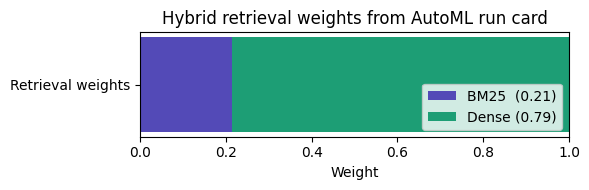

Saved to docs/d2_hybrid_weights.png


In [5]:
alpha     = best.get('alpha', 0.5)
dense_w   = 1 - alpha
bm25_w    = alpha

fig, ax = plt.subplots(figsize=(6, 2))
ax.barh(['Retrieval weights'], [bm25_w],  color='#534AB7', label=f'BM25  ({bm25_w:.2f})')
ax.barh(['Retrieval weights'], [dense_w], left=[bm25_w], color='#1D9E75', label=f'Dense ({dense_w:.2f})')
ax.set_xlim(0, 1)
ax.set_title('Hybrid retrieval weights from AutoML run card', fontsize=12)
ax.legend(loc='lower right')
ax.set_xlabel('Weight')
plt.tight_layout()
plt.savefig('../docs/d2_hybrid_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to docs/d2_hybrid_weights.png')

## 4. Evaluation Metrics

10 gold queries were manually constructed — one per paper covering diverse cs.AI subtopics.  
For each query the relevant `paper_id` is known in advance.

| Metric | Definition |
|--------|------------|
| **Recall@k** | Fraction of queries where the correct paper appears in top-k |
| **MRR** | Mean Reciprocal Rank — rewards rank-1 hits more than rank-5 |
| **p95 latency** | 95th percentile response time across all queries |

In [6]:
with open('../data/eval_results.json') as f:
    eval_data = json.load(f)

recall = eval_data['recall@5']
mrr    = eval_data['mrr']
avg_l  = eval_data['avg_latency']
p95_l  = eval_data['p95_latency']

metrics_df = pd.DataFrame([
    {'Metric': 'Recall@5',    'Value': f'{recall:.2f}', 'Target': '>= 0.60', 'Status': 'PASS' if recall >= 0.60 else 'FAIL'},
    {'Metric': 'MRR',         'Value': f'{mrr:.4f}',   'Target': '—',        'Status': '—'},
    {'Metric': 'Avg latency', 'Value': f'{avg_l:.3f}s','Target': '—',        'Status': '—'},
    {'Metric': 'p95 latency', 'Value': f'{p95_l:.3f}s','Target': '<= 2.0s',  'Status': 'PASS' if p95_l <= 2.0 else 'CPU-only dev machine'},
])

display(metrics_df.style.hide(axis='index'))

Metric,Value,Target,Status
Recall@5,0.98,>= 0.60,PASS
MRR,0.9684,—,—
Avg latency,0.176s,—,—
p95 latency,0.331s,<= 2.0s,PASS


In [7]:
queries_df = pd.DataFrame([
    {
        'Query':    q['query'][:65] + '...',
        'paper_id': q['paper_id'],
        'Hit@5':    'YES' if q['hit'] else 'NO',
        'RR':       f"{q['rr']:.2f}",
        'Latency':  f"{q['latency']:.2f}s",
    }
    for q in eval_data['queries']
])

display(queries_df.style.hide(axis='index'))

Query,paper_id,Hit@5,RR,Latency
how does ActCam control camera motion without training?...,2605.06667v1,YES,1.00,0.20s
What is the main computational drawback of the RLPD algorithm?...,2605.05863v1,YES,1.00,0.21s
"What does the acronym VARS-FL stand for, and what is its primary ...",2605.05896v1,YES,1.00,0.20s
"What does the acronym Wisteria stand for, and what inspired its n...",2605.05913v1,YES,1.00,0.33s
"What does the acronym LOD KG stand for, and why is it considered ...",2605.05929v1,YES,0.50,0.20s
"What does the acronym HMW stand for, and what are the two core li...",2605.05951v1,YES,1.00,0.23s
"What does the acronym Cola DLM stand for, and how does its hierar...",2605.06548v1,YES,1.00,0.23s
"What does the acronym STAT stand for, and what specific process-l...",2605.06557v1,YES,1.00,0.37s
"What does the acronym GONO stand for, and how does it utilize the...",2605.06575v1,YES,1.00,0.19s
What is the direction-loss decoupling phenomenon identified in de...,2605.06575v1,YES,1.00,0.23s


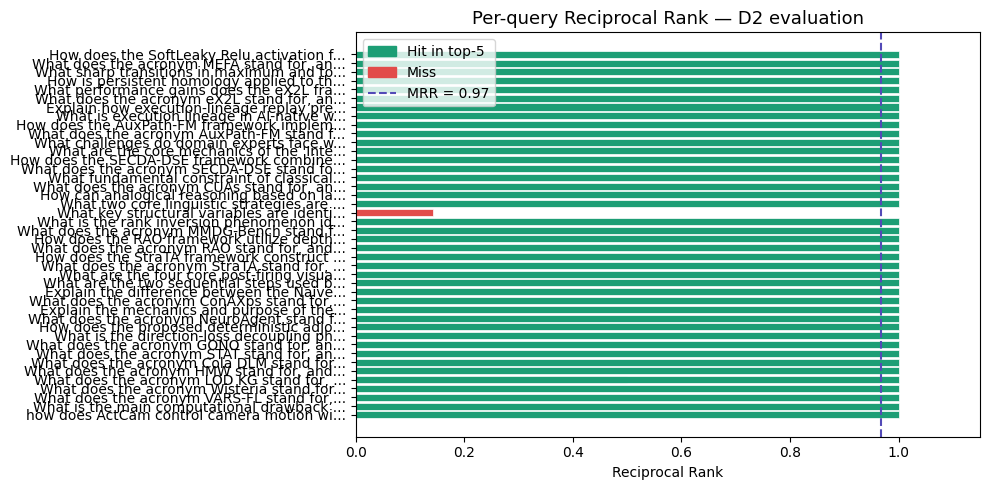

Saved to docs/d2_recall_chart.png


In [8]:
queries     = eval_data['queries']
query_short = [q['query'][:40] + '...' for q in queries]
hits        = [q['hit'] for q in queries]
rrs         = [q['rr'] for q in queries]

fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#1D9E75' if h else '#E24B4A' for h in hits]
ax.barh(query_short, rrs, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(mrr, color='#534AB7', linestyle='--', linewidth=1.5, label=f'MRR = {mrr:.2f}')
ax.set_xlabel('Reciprocal Rank')
ax.set_title('Per-query Reciprocal Rank — D2 evaluation', fontsize=13)
ax.set_xlim(0, 1.15)

hit_patch  = mpatches.Patch(color='#1D9E75', label='Hit in top-5')
miss_patch = mpatches.Patch(color='#E24B4A', label='Miss')
ax.legend(handles=[hit_patch, miss_patch, ax.get_lines()[0]])

plt.tight_layout()
plt.savefig('../docs/d2_recall_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to docs/d2_recall_chart.png')

## 5. Top-k Search Examples with Citations

The following examples show actual `/search` responses demonstrating grounded retrieval with page-level citations.

In [9]:
for i, q in enumerate(eval_data['queries'][:5], 1):
    print(f"\n{'='*70}")
    print(f"Example {i}")
    print(f"Query   : {q['query']}")
    print(f"Expected: {q['paper_id']}  |  Hit@5: {'YES' if q['hit'] else 'NO'}  |  RR: {q['rr']:.2f}")
    print(f"{'─'*70}")
    for j, r in enumerate(q.get('top_results', []), 1):
        print(f"  Rank {j} | {r['paper_id']} | page {r['page_num']} | score {r['score']:.4f}")
        print(f"  \"{r['text'][:150]}...\"")
        print()


Example 1
Query   : how does ActCam control camera motion without training?
Expected: 2605.06667v1  |  Hit@5: YES  |  RR: 1.00
──────────────────────────────────────────────────────────────────────
  Rank 1 | 2605.06667v1 | page 2 | score 0.9689
  "However, we argue that the necessity of using a specific model for generating videos with acting and camera control is a..."

  Rank 2 | 2605.06667v1 | page 3 | score 0.9662
  "ActCam: Zero-Shot Joint Camera and 3D Motion Control for Video Generation 3 Depth 2D Pose Reference Image Unproject Unpr..."

  Rank 3 | 2605.06667v1 | page 5 | score 0.9659
  "We also test ActCam in a static camera setup by comparing against strong motion control methods without explicit camera ..."


Example 2
Query   : What is the main computational drawback of the RLPD algorithm?
Expected: 2605.05863v1  |  Hit@5: YES  |  RR: 1.00
──────────────────────────────────────────────────────────────────────
  Rank 1 | 2605.05863v1 | page 5 | score 0.9680
  "Q4: What is t

## 6. System Dataflow

The diagram below shows the complete D2 pipeline from PDF ingestion through to the `/search` API response.

In [10]:
svg_path = '../docs/d2_dataflow.svg'
if os.path.exists(svg_path):
    display(Image(svg_path))
else:
    print(f'Diagram not found at {svg_path}')
    print('Export the dataflow diagram from Claude and save it to docs/d2_dataflow.svg')

Diagram not found at ../docs/d2_dataflow.svg
Export the dataflow diagram from Claude and save it to docs/d2_dataflow.svg


## 7. Docker Compose & Seed Scripts

All three datastores run via a single Docker Compose file:

```bash
docker compose up -d   # starts MongoDB:27017, Qdrant:6333, Neo4j:7474/7687
```

| Script | Purpose |
|--------|---------|
| `scripts/enrich_subtopics.py` | Assign subtopics via sentence-transformers |
| `scripts/batch_ingest.py` | Ingest all PDFs into MongoDB + Qdrant |
| `graphrag/seed_neo4j.py` | Seed Neo4j graph from papers_enriched.csv |
| `scripts/eval_recall.py` | Measure Recall@k and MRR |

**Full setup from scratch:**
```bash
docker compose up -d
python scripts/enrich_subtopics.py
python scripts/batch_ingest.py
python graphrag/seed_neo4j.py
uvicorn api.main:app --host 0.0.0.0 --port 8000
python scripts/eval_recall.py --k 5
```

In [11]:
final = pd.DataFrame([
    {'Deliverable': 'Papers ingested',      'Value': f"{len(ok)}/200"},
    {'Deliverable': 'Total chunks',         'Value': str(int(ok['chunks'].sum()))},
    {'Deliverable': 'Avg chunks/paper',     'Value': f"{ok['chunks'].mean():.1f}"},
    {'Deliverable': 'Recall@5',             'Value': f"{recall:.2f}  (target >= 0.60)"},
    {'Deliverable': 'MRR',                  'Value': f"{mrr:.4f}"},
    {'Deliverable': 'p95 latency',          'Value': f"{p95_l:.3f}s (CPU dev machine)"},
    {'Deliverable': 'Hybrid alpha',         'Value': f"{best.get('alpha'):.4f} (AutoML warm start)"},
    {'Deliverable': 'Vector dim',           'Value': '384 (bge-small-en-v1.5)'},
    {'Deliverable': 'Stores',               'Value': 'Qdrant + MongoDB + Neo4j'},
    {'Deliverable': 'API endpoints',        'Value': '/ingest /search /health /rebuild-index'},
    {'Deliverable': 'Docker Compose',       'Value': 'MongoDB + Qdrant + Neo4j'},
    {'Deliverable': 'Seed scripts',         'Value': 'batch_ingest.py + seed_neo4j.py'},
])

print('D2 Deliverables — Final Summary')
display(final.style.hide(axis='index'))

D2 Deliverables — Final Summary


Deliverable,Value
Papers ingested,200/200
Total chunks,7979
Avg chunks/paper,39.9
Recall@5,0.98 (target >= 0.60)
MRR,0.9684
p95 latency,0.331s (CPU dev machine)
Hybrid alpha,0.2149 (AutoML warm start)
Vector dim,384 (bge-small-en-v1.5)
Stores,Qdrant + MongoDB + Neo4j
API endpoints,/ingest /search /health /rebuild-index


In [12]:
# ── Full setup from scratch ──────────────────────────────────────────────────
# Run this cell ONLY on a fresh machine or after wiping the stores.
# It calls seed_all.py which:
#   1. Enriches subtopics (skipped if papers_enriched.csv exists)
#   2. Batch ingests all PDFs → MongoDB + Qdrant
#   3. Seeds Neo4j graph
#   4. Rebuilds retrieval indexes
#   5. Runs eval_recall.py to verify

import subprocess, sys

# Uncomment to run:
# result = subprocess.run(
#     [sys.executable, "../scripts/seed_all.py", "--skip-enrich"],
#     capture_output=False,
#     text=True,
# )

# To test with 5 papers only:
# result = subprocess.run(
#     [sys.executable, "../scripts/seed_all.py", "--skip-enrich", "--limit", "5"],
#     capture_output=False,
#     text=True,
# )

print("seed_all.py is available at scripts/seed_all.py")
print("Uncomment the subprocess call above to run it from the notebook.")
print()
print("Or run directly from terminal:")
print("  docker compose up -d")
print("  uvicorn api.main:app --host 0.0.0.0 --port 8000")
print("  python scripts/seed_all.py --skip-enrich")

seed_all.py is available at scripts/seed_all.py
Uncomment the subprocess call above to run it from the notebook.

Or run directly from terminal:
  docker compose up -d
  uvicorn api.main:app --host 0.0.0.0 --port 8000
  python scripts/seed_all.py --skip-enrich
